In [1]:
import manim as mn
from manim import *

config.media_width = "75%"
config.verbosity = "WARNING"

print(mn.__version__)



0.20.1


In [2]:
%%manim -qm Doppler

current_frame = 0

class Doppler(Scene):

    def construct(self):
        
        source=Dot()
        
        #creates a group to store the wavefronts
        waves=VGroup() 

        
        #function to add each wavefront
        def addwavefront(mob,dt):

            global current_frame

            wavefront=Circle(
                radius=0.01,
                color=YELLOW,
                stroke_width=1.5,
                arc_center=source.get_center()
            ) 
            current_frame += 1
            if current_frame%8 == 0: #frequency of the wave
                waves.add(wavefront)
            return current_frame

        #function to expand and fade away each wavefront
        def expandwaves(mob, dt):

            for wavefront in waves:
                wavefront.scale_to_fit_width(wavefront.width + 0.055)#wave speed
                wavefront.set_stroke(opacity = 1 - wavefront.width/20)
                if (1 - wavefront.width/20) == 0:
                    waves.remove(wavefront)
    

        waves.add_updater(addwavefront)
        waves.add_updater(expandwaves)

        self.add(source)
        self.add(waves)

        self.wait(2)
        self.play(
                source.animate.shift(RIGHT*5), rate_func=linear, run_time=10
        )
        self.play(
                source.animate.shift(LEFT*8), run_time=5
        )
        waves.remove_updater(addwavefront)
        self.wait(1)
        self.play(FadeOut(waves), FadeOut(source))
        self.wait(1)
        
#if you want to change the frequency of pulse emission, 
#you need to simply change the number after % in the  if current_frame%8 == 0: line

Manim Community v0.20.1

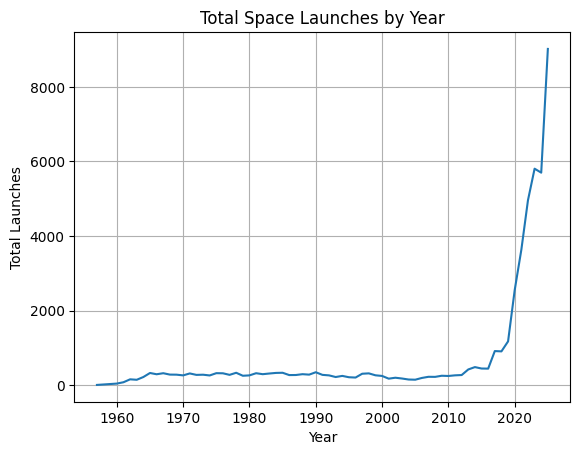

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
yearlylaunchdata = pd.read_csv('yearlylaunchdata.csv')

by_year = yearlylaunchdata.groupby('Year').sum()
by_year.drop(columns=['Entity', 'Code'], inplace=True)
plt.plot(by_year.index, by_year['Annual number of objects launched into outer space'])
plt.xlabel('Year')
plt.ylabel('Total Launches')
plt.title('Total Space Launches by Year')
plt.grid()
plt.show()


In [6]:
%%manim -qm BarChartExample

from manim import *

class BarChartExample(Scene):
    def construct(self):
        chart = BarChart(
            values=[-5, 40, -10, 20, -3],
            bar_names=["one", "two", "three", "four", "five"],
            y_range=[-20, 50, 10],
            y_length=6,
            x_length=10,
            x_axis_config={"font_size": 36},
        )

        c_bar_lbls = chart.get_bar_labels(font_size=48)

        self.add(chart, c_bar_lbls)

Manim Community v0.20.1

FileNotFoundError: [Errno 2] No such file or directory: 'latex'